<a href="https://colab.research.google.com/github/WilfredoPS/MLInvestigacionDecisionTreeGroup/blob/main/CHAID_Decision_Tree_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Algoritmo CHAID — Árbol de Decisión
**Tarea 1 – Investigación en Grupo | Módulo: Algoritmos de Machine Learning**

---

## 1. Descripción del Algoritmo

**CHAID** (Chi-squared Automatic Interaction Detection) es un algoritmo de aprendizaje supervisado para la construcción de árboles de decisión, propuesto originalmente por **Gordon Kass** en 1980. Es una extensión del algoritmo AID (Automatic Interaction Detection) de Morgan y Sonquist (1963).

El algoritmo construye un árbol de decisión utilizando la **prueba Chi-cuadrado (χ²)** para variables nominales y ordinales, y la **prueba F** para variables continuas, con el objetivo de determinar la variable independiente que mejor predice la variable dependiente en cada nodo.

A diferencia de ID3, C4.5 y CART, CHAID puede:
- Generar **ramas múltiples** en cada nodo (no solo divisiones binarias)
- Manejar **variables nominales, ordinales y continuas** (discretizando las continuas)
- Realizar **fusiones automáticas** de categorías no significativamente diferentes
- Controlar el crecimiento del árbol mediante el **nivel de significancia estadística (alpha)**

## 2. Publicación que Propuso el Algoritmo (BibTeX y Referencias)

### BibTeX Original — CHAID (Kass, 1980)
```bibtex
@article{kass1980exploratory,
  title     = {An Exploratory Technique for Investigating Large Quantities of Categorical Data},
  author    = {Kass, Gordon V.},
  journal   = {Journal of the Royal Statistical Society. Series C (Applied Statistics)},
  volume    = {29},
  number    = {2},
  pages     = {119--127},
  year      = {1980},
  publisher = {Wiley for the Royal Statistical Society}
}
```

### BibTeX — CHAID Exhaustivo (Biggs et al., 1991)
```bibtex
@article{biggs1991method,
  title   = {A Method of Choosing Multiway Partitions for Classification and Decision Trees},
  author  = {Biggs, David and de Ville, Barry and Suen, Ed},
  journal = {Journal of Applied Statistics},
  volume  = {18},
  number  = {1},
  pages   = {49--62},
  year    = {1991}
}
```

### Referencias APA
- Kass, G. V. (1980). An exploratory technique for investigating large quantities of categorical data. *Journal of the Royal Statistical Society: Series C (Applied Statistics), 29*(2), 119–127.
- Biggs, D., de Ville, B., & Suen, E. (1991). A method of choosing multiway partitions for classification and decision trees. *Journal of Applied Statistics, 18*(1), 49–62.

## 3. Tipo de Modelo

| Dimensión | Clasificación |
|---|---|
| **Método de Aprendizaje** | Aprendizaje Supervisado — Clasificación y Regresión |
| **Por Parámetros** | No Paramétrico — no asume ninguna distribución estadística |
| **Datos de Aprendizaje** | Offline / Batch — se entrena con todo el conjunto de datos a la vez |
| **Resultado del Entrenamiento** | Basado en Modelo — genera un árbol de decisión multivía |

## 4. Algoritmo de Entrenamiento

CHAID utiliza pruebas estadísticas para seleccionar el mejor atributo de división:

### Fórmulas clave:

**Chi-cuadrado (para variables nominales/ordinales):**
$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

donde $O_{ij}$ son las frecuencias observadas y $E_{ij}$ las esperadas.

**Valor esperado:**
$$E_{ij} = \frac{(\text{Total fila}_i) \times (\text{Total columna}_j)}{\text{Total general}}$$

### Proceso:
1. Para cada variable independiente, calcular el **valor-p** de la prueba χ² con la variable objetivo
2. **Fusionar** categorías cuyo valor-p supere el umbral de Bonferroni ajustado
3. Seleccionar la variable con **menor valor-p** (más significativa) como nodo de división
4. Si el valor-p < α (umbral de fusión, por defecto 0.05), dividir el nodo
5. Repetir recursivamente hasta alcanzar criterios de parada
6. **No requiere poda** — el crecimiento se controla mediante α

## 5. Tipos de Entrada

- **Atributos nominales** (ej: color, tipo, categoría) — usa prueba χ²
- **Atributos ordinales** (ej: nivel educativo, escalas) — usa χ² con restricción de orden
- **Atributos numéricos/continuos** (ej: edad, temperatura) — se **discretizan en bins** antes del análisis
- **Variable objetivo:** categórica (clasificación) o numérica (regresión con prueba F)
- **Formato de entrada:** tabla/dataset con filas=muestras, columnas=características

## 6. Casos de Uso

| Área | Aplicación |
|---|---|
| 📊 Marketing | Segmentación de clientes por comportamiento de compra |
| 🏥 Medicina | Identificación de factores de riesgo en poblaciones |
| 💳 Finanzas | Clasificación de clientes para aprobación de créditos |
| 📋 Encuestas | Análisis de datos de encuestas con variables categóricas |
| 🎓 Educación | Predicción de rendimiento académico por factores sociales |
| 🛒 Retail | Análisis de patrones de compra y perfiles de consumidor |

## 7. Supuestos y Restricciones

### Supuestos:
- Las observaciones son independientes entre sí
- Las variables independientes pueden ser nominales, ordinales o continuas (discretizadas)
- El tamaño de la muestra debe ser suficiente para que la prueba χ² sea válida

### Restricciones:
- Las variables **continuas deben discretizarse** antes del análisis (pérdida de información)
- Puede ser **inestable** con muestras pequeñas por dependencia del valor-p
- Los árboles pueden ser **difíciles de interpretar** cuando tienen muchas ramas
- **Sesgo hacia variables con muchas categorías** (similar a ID3 con muchos valores únicos)
- No maneja directamente **valores faltantes** sin preprocesamiento previo

## 8. Source Code — Implementación en Python

Usaremos la librería `CHAID` (implementación en Python del algoritmo CHAID) junto con `scikit-learn` para la evaluación del modelo.

In [ ]:
# Instalación (solo necesario en Colab si no está disponible)
# !pip install CHAID scikit-learn matplotlib pandas seaborn scipy

In [ ]:
import sys
!{sys.executable} -m pip install CHAID

# ============================================================
# PASO 1: Importar librerías
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from CHAID import Tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [ ]:
# ============================================================
# PASO 2: Cargar dataset (Iris — clásico para clasificación)
# ============================================================
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

# Renombrar columnas para facilitar el manejo (sin espacios ni paréntesis)
X.columns = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
y = pd.Series(iris.target, name='species')

print('Shape del dataset:', X.shape)
print('Clases:', iris.target_names)
X.head()

Shape del dataset: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# ============================================================
# PASO 3: División Train / Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 105 muestras
Test:  45 muestras


In [ ]:
# ============================================================
# PASO 4: Discretizar variables continuas
# CHAID requiere variables categóricas/ordinales.
# Usamos pd.qcut para dividir en 5 bins de igual frecuencia.
# ============================================================
feature_cols_orig = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
feature_cols_bin  = [c + '_bin' for c in feature_cols_orig]

df_train = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1
)

# Guardar los bordes de bins del entrenamiento para aplicar al test
bins = {}
for col in feature_cols_orig:
    df_train[col + '_bin'], bin_edges = pd.qcut(
        df_train[col], q=5, labels=False, duplicates='drop', retbins=True
    )
    bins[col] = bin_edges
    df_train[col + '_bin'] = df_train[col + '_bin'].astype(int)

print('Discretización completada. Bins por característica:')
for col, edges in bins.items():
    print(f'  {col}: {len(edges)-1} intervalos')

df_train[feature_cols_bin].head()

Discretización completada. Bins por característica:
  sepal_length_cm: 5 intervalos
  sepal_width_cm: 5 intervalos
  petal_length_cm: 5 intervalos
  petal_width_cm: 5 intervalos


,sepal_length_cm_bin,sepal_width_cm_bin,petal_length_cm_bin,petal_width_cm_bin
0,0,0,1,1
1,3,0,2,2
2,0,4,0,1
3,4,3,4,4
4,2,1,2,2


In [ ]:
# ============================================================
# PASO 5: Entrenar el modelo CHAID
# alpha_merge: nivel de significancia para fusionar / dividir (0.05)
# max_depth:   profundidad máxima del árbol
# min_parent_node_size: mínimo de muestras en un nodo para dividir
# ============================================================
chaid_cols = {col: 'ordinal' for col in feature_cols_bin}

modelo_chaid = Tree.from_pandas_df(
    df_train,
    chaid_cols,
    'species',
    alpha_merge=0.05,
    max_depth=4,
    min_parent_node_size=5,
    min_child_node_size=5,
    dep_variable_type='categorical'
)

print('Modelo CHAID entrenado con éxito')
print(f'Número de nodos en el árbol: {len(modelo_chaid.tree_store)}')

Modelo CHAID entrenado con éxito
Número de nodos en el árbol: 9


In [ ]:
# ============================================================
# PASO 6: Visualizar el Árbol CHAID
# ============================================================
print('Estructura del Árbol CHAID — Dataset Iris')
print('=' * 55)
modelo_chaid.print_tree()

Estructura del Árbol CHAID — Dataset Iris
([], {0: 35.0, 1: 35.0, 2: 35.0}, (petal_width_cm_bin, p=2.6563705475586906e-33, score=166.3625730994152, groups=[[0], [1], [2], [3, 4]]), dof=6))
|-- ([0], {0: 23.0, 1: 0, 2: 0}, <Invalid Chaid Split> - the node only contains single category respondents)
|-- ([1], {0: 12.0, 1: 7.0, 2: 0}, (petal_length_cm_bin, p=0.0015867999576902182, score=9.975, groups=[[0], [1, 2]]), dof=1))
|   |-- ([0], {0: 9.0, 1: 0, 2: 0}, <Invalid Chaid Split> - the node only contains single category respondents)
|   +-- ([1, 2], {0: 3.0, 1: 7.0, 2: 0}, <Invalid Chaid Split> - the node only contains single category respondents)
|-- ([2], {0: 0, 1: 26.0, 2: 1.0}, <Invalid Chaid Split> - the node only contains single category respondents)
+-- ([3, 4], {0: 0, 1: 2.0, 2: 34.0}, (sepal_length_cm_bin, p=0.006479873248596332, score=7.411764705882353, groups=[[1, 2], [3, 4]]), dof=1))
    |-- ([1, 2], {0: 0, 1: 2.0, 2: 6.0}, <Invalid Chaid Split> - p-value greater than alpha m

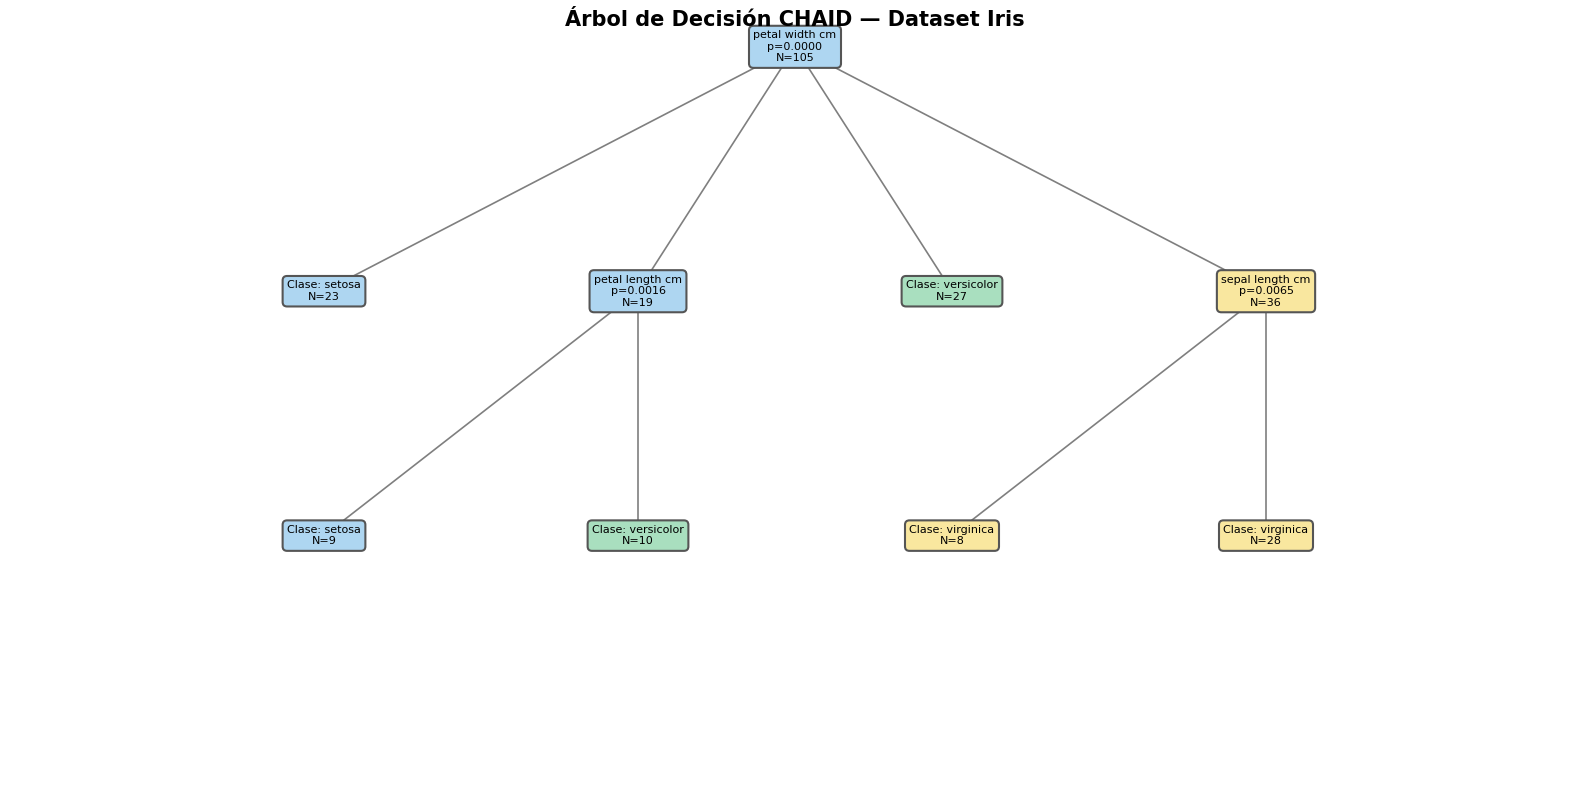

In [ ]:
# ============================================================
# PASO 6b: Visualización gráfica del árbol con Matplotlib
# ============================================================
def draw_chaid_tree(tree_store, class_names, feature_names):
    """Dibuja el árbol CHAID usando Matplotlib."""
    # Construir mapa hijo -> nodo padre y padre -> hijos
    children_map = {}
    for nid, node in enumerate(tree_store):
        if node.parent is not None:
            children_map.setdefault(node.parent, []).append(nid)

    # Calcular posiciones mediante BFS
    pos = {}
    level_nodes = {0: [0]}
    levels = {0: 0}
    queue = [0]
    while queue:
        nid = queue.pop(0)
        children = children_map.get(nid, [])
        for child in children:
            levels[child] = levels[nid] + 1
            level_nodes.setdefault(levels[nid] + 1, []).append(child)
            queue.append(child)

    max_level = max(levels.values()) if levels else 0
    for lv in range(max_level + 1):
        nodes_at_level = level_nodes.get(lv, [])
        n = len(nodes_at_level)
        for i, nid in enumerate(nodes_at_level):
            pos[nid] = ((i + 1) / (n + 1), 1 - lv / (max_level + 1))

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Colores por clase mayoritaria
    colors = ['#AED6F1', '#A9DFBF', '#F9E79F', '#F1948A']

    # Dibujar aristas
    for nid, node in enumerate(tree_store):
        for child_id in children_map.get(nid, []):
            x0, y0 = pos[nid]
            x1, y1 = pos[child_id]
            ax.plot([x0, x1], [y0, y1], 'k-', lw=1.2, alpha=0.5, zorder=1)

    # Dibujar nodos
    for nid, node in enumerate(tree_store):
        x, y = pos[nid]
        majority_class = max(node.members, key=node.members.get)
        color = colors[int(majority_class) % len(colors)]
        total = sum(node.members.values())

        # Etiqueta del nodo
        if node.is_terminal:
            label = f'Clase: {class_names[int(majority_class)]}\nN={int(total)}'
        else:
            col_name = node.split.column.replace('_bin', '').replace('_', ' ')
            p_val = node.split.p if hasattr(node.split, 'p') else 0
            label = f'{col_name}\np={p_val:.4f}\nN={int(total)}'

        bbox = dict(boxstyle='round,pad=0.4', facecolor=color, edgecolor='#555', linewidth=1.5)
        ax.text(x, y, label, ha='center', va='center', fontsize=8,
                bbox=bbox, zorder=2)

    ax.set_title('Árbol de Decisión CHAID — Dataset Iris', fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

draw_chaid_tree(modelo_chaid.tree_store, iris.target_names,
                [c.replace('_bin','') for c in feature_cols_bin])

In [ ]:
# ============================================================
# PASO 7: Evaluación del modelo
# Primero discretizamos el conjunto de test usando los MISMOS
# bordes de bins calculados en entrenamiento.
# ============================================================

# --- Discretizar test con bins del entrenamiento ---
df_test = X_test.copy().reset_index(drop=True)
for col in feature_cols_orig:
    df_test[col + '_bin'] = pd.cut(
        df_test[col], bins=bins[col], labels=False, include_lowest=True
    )
    df_test[col + '_bin'] = df_test[col + '_bin'].fillna(0).astype(int)

# --- Construir mapa padre -> hijos para recorrer el árbol ---
children_map = {}
for nid, node in enumerate(modelo_chaid.tree_store):
    if node.parent is not None:
        children_map.setdefault(node.parent, []).append(nid)

def predict_chaid(tree, row_dict, children_map):
    """Recorre el árbol CHAID para predecir la clase de una muestra."""
    node_id = 0
    while True:
        node = tree.tree_store[node_id]
        if node.is_terminal:
            return max(node.members, key=node.members.get)
        split_col = node.split.column
        val = int(row_dict.get(split_col, 0))
        splits = node.split.splits          # lista de listas de enteros
        children = children_map.get(node_id, [])
        matched = False
        for child_id, group in zip(children, splits):
            if val in group:
                node_id = child_id
                matched = True
                break
        if not matched:
            # Si no hay coincidencia, ir al hijo más poblado
            node_id = max(children,
                          key=lambda c: sum(tree.tree_store[c].members.values()))

# --- Predecir sobre el conjunto de test ---
preds = []
for _, row in df_test.iterrows():
    row_dict = {col: int(row[col]) for col in feature_cols_bin}
    pred = predict_chaid(modelo_chaid, row_dict, children_map)
    preds.append(pred)

y_pred = np.array(preds)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 82.22 %

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      0.80      0.89        15
  versicolor       0.71      0.80      0.75        15
   virginica       0.81      0.87      0.84        15

    accuracy                           0.82        45
   macro avg       0.84      0.82      0.83        45
weighted avg       0.84      0.82      0.83        45



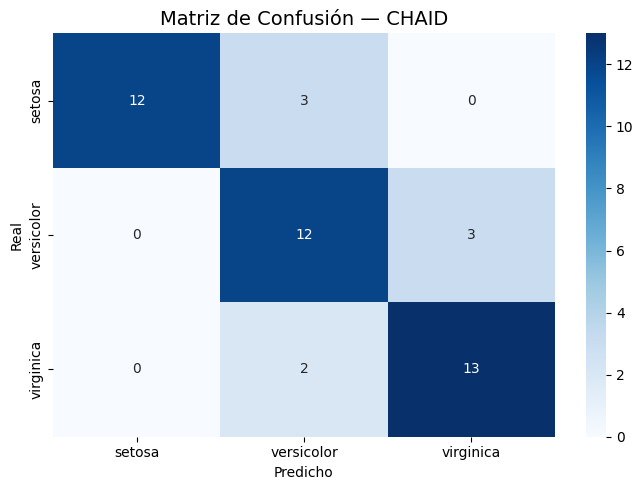

In [ ]:
# ============================================================
# PASO 8: Matriz de Confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matriz de Confusión — CHAID', fontsize=14)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

Número de nodos hoja (terminales): 6

 Nodo  Total  setosa  versicolor  virginica Clase mayoritaria  Pureza (%)
    1     23      23           0          0            setosa       100.0
    3      9       9           0          0            setosa       100.0
    4     10       3           7          0        versicolor        70.0
    5     27       0          26          1        versicolor        96.3
    7      8       0           2          6         virginica        75.0
    8     28       0           0         28         virginica       100.0


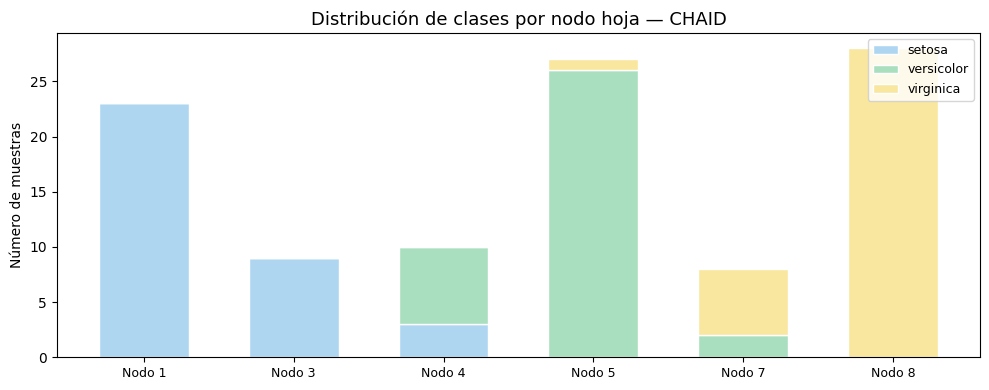

In [ ]:
# ============================================================
# PASO 9: Distribución de clases por nodo hoja
# ============================================================
terminal_nodes = [(nid, node) for nid, node in enumerate(modelo_chaid.tree_store)
                  if node.is_terminal]

print(f'Número de nodos hoja (terminales): {len(terminal_nodes)}')
print()

data = []
for nid, node in terminal_nodes:
    total = sum(node.members.values())
    majority = max(node.members, key=node.members.get)
    purity = node.members[majority] / total * 100 if total > 0 else 0
    data.append({
        'Nodo': nid,
        'Total': int(total),
        'setosa': int(node.members.get(0, 0)),
        'versicolor': int(node.members.get(1, 0)),
        'virginica': int(node.members.get(2, 0)),
        'Clase mayoritaria': iris.target_names[int(majority)],
        'Pureza (%)': round(purity, 1)
    })

df_nodos = pd.DataFrame(data)
print(df_nodos.to_string(index=False))

# Gráfico de barras apiladas por nodo
fig, ax = plt.subplots(figsize=(10, 4))
bar_width = 0.6
x = range(len(df_nodos))
colors_class = ['#AED6F1', '#A9DFBF', '#F9E79F']
bottom = np.zeros(len(df_nodos))
for i, cls in enumerate(['setosa', 'versicolor', 'virginica']):
    ax.bar(x, df_nodos[cls].values, bottom=bottom,
           label=cls, color=colors_class[i], edgecolor='white', width=bar_width)
    bottom += df_nodos[cls].values

ax.set_xticks(list(x))
ax.set_xticklabels([f'Nodo {n}' for n in df_nodos['Nodo']], fontsize=9)
ax.set_ylabel('Número de muestras')
ax.set_title('Distribución de clases por nodo hoja — CHAID', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PASO 10: Predicción con nuevos datos
# ============================================================
# Ejemplo: nueva flor con medidas [sépalo largo, sépalo ancho, pétalo largo, pétalo ancho]
nueva_muestra = np.array([[5.1, 3.5, 1.4, 0.2]])  # Probablemente setosa
nueva_df = pd.DataFrame(nueva_muestra,
                        columns=feature_cols_orig)

# Discretizar la muestra nueva con los bins del entrenamiento
for col in feature_cols_orig:
    nueva_df[col + '_bin'] = pd.cut(
        nueva_df[col], bins=bins[col], labels=False, include_lowest=True
    )
    nueva_df[col + '_bin'] = nueva_df[col + '_bin'].fillna(0).astype(int)

row_dict_nueva = {col: int(nueva_df[col].iloc[0]) for col in feature_cols_bin}
prediccion = predict_chaid(modelo_chaid, row_dict_nueva, children_map)

print(f'Predicción: {iris.target_names[int(prediccion)]}')
print()
# Obtener el nodo terminal correspondiente para mostrar distribución
node_id = 0
while True:
    node = modelo_chaid.tree_store[node_id]
    if node.is_terminal:
        break
    split_col = node.split.column
    val = row_dict_nueva.get(split_col, 0)
    splits = node.split.splits
    children = children_map.get(node_id, [])
    matched = False
    for child_id, group in zip(children, splits):
        if val in group:
            node_id = child_id
            matched = True
            break
    if not matched:
        node_id = max(children, key=lambda c: sum(modelo_chaid.tree_store[c].members.values()))

total_nodo = sum(node.members.values())
print('Distribución en el nodo terminal asignado:')
for cls_id, cls_name in enumerate(iris.target_names):
    cnt = node.members.get(cls_id, 0)
    prob = cnt / total_nodo * 100 if total_nodo > 0 else 0
    print(f'   {cls_name}: {prob:.2f}%')

Predicción: setosa

Distribución en el nodo terminal asignado:
   setosa: 100.00%
   versicolor: 0.00%
   virginica: 0.00%


## 9. Comparación CHAID vs C4.5 vs CART

| Característica | CHAID | C4.5 | CART |
|---|---|---|---|
| **Criterio de división** | Chi-cuadrado / Prueba F | Ratio de Ganancia | Índice de Gini |
| **Tipo de árbol** | Multivía (n ramas) | Binario/Multivía | Binario |
| **Poda** | No requiere (controlado por α) | Post-poda (pessimistic) | Pre y post-poda |
| **Variables continuas** | Requiere discretización | Manejo automático | Manejo automático |
| **Valores faltantes** | No maneja directamente | Sí | Sí (subrogados) |
| **Interpretabilidad** | Alta (estadística clara) | Moderada | Alta |
| **Velocidad** | Moderada | Moderada | Rápida |

> **CHAID** es especialmente popular en **investigación de mercados** y **ciencias sociales** por su fundamento estadístico y la facilidad para interpretar las divisiones mediante valores-p.

  CHAID                Accuracy: 82.22%
  C4.5 (entropy)       Accuracy: 88.89%
  CART (gini)          Accuracy: 93.33%


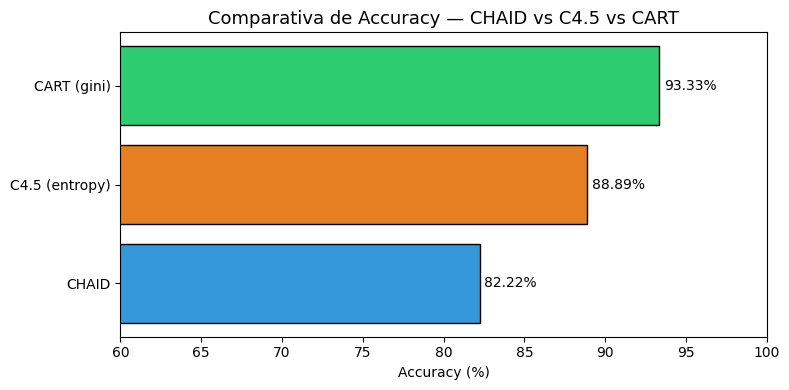

In [ ]:
# ============================================================
# COMPARATIVA: CHAID vs C4.5 vs CART
# ============================================================
from sklearn.tree import DecisionTreeClassifier

# C4.5 aproximado (criterion='entropy')
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=5,
                              min_samples_split=5, random_state=42)
c45.fit(X_train, y_train)
acc_c45 = accuracy_score(y_test, c45.predict(X_test))

# CART (criterion='gini')
cart = DecisionTreeClassifier(criterion='gini', max_depth=5,
                               min_samples_split=5, random_state=42)
cart.fit(X_train, y_train)
acc_cart = accuracy_score(y_test, cart.predict(X_test))

# CHAID
acc_chaid = accuracy_score(y_test, y_pred)

modelos = ['CHAID', 'C4.5 (entropy)', 'CART (gini)']
accuracies = [acc_chaid * 100, acc_c45 * 100, acc_cart * 100]

print('=' * 45)
for m, a in zip(modelos, accuracies):
    print(f'  {m:<20} Accuracy: {a:.2f}%')
print('=' * 45)

plt.figure(figsize=(8, 4))
bars = plt.barh(modelos, accuracies,
                color=['#3498DB', '#E67E22', '#2ECC71'], edgecolor='black')
plt.xlim(60, 100)
plt.xlabel('Accuracy (%)')
plt.title('Comparativa de Accuracy — CHAID vs C4.5 vs CART', fontsize=13)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{acc:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()